# Cluster maps

In [2]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import pyccl as ccl
from ulid import ULID

from iminuit import Minuit
from iminuit.cost import LeastSquares

from simulMap import *

In [3]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152
Total number of sources in the entire sky : 49152000000
Theorical number of sources in one pixel : 1000000


## Power spectrum

/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: Nchi must be a positive integer. Setting to match tracer with fewest chi samples.
  warnings_builtin.warn(*args, **kwargs)
/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: chi_min must be greater than zero.Setting to default 1e-6 Mpc.
  warnings_builtin.warn(*args, **kwargs)


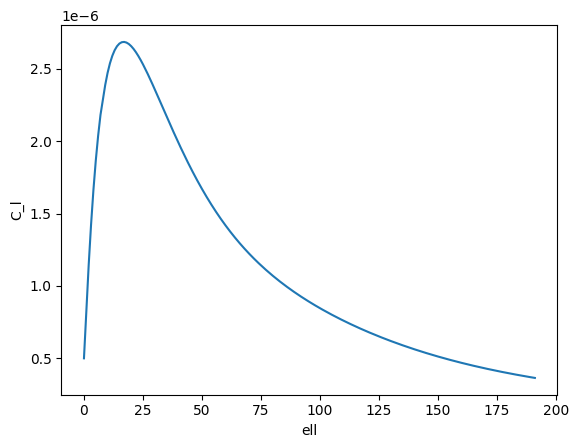

In [4]:
def nz_model(z):
    """Compute the normalized distribution in redshift dependong on the redshift z."""
    return z**2 * np.exp(-(z/0.5)**1.5)


def build_nz(zmin):
    z = np.linspace(0.01, 3.0, 400)
    nz = nz_model(z)
    nz[z < zmin] = 0
    nz /= np.trapz(nz, z)
    return z, nz


def get_Cl_ccl(nside, zmin, Omega_c=0.25, Omega_b=0.05, h=0.67, sigma8=0.8, n_s=0.96, get_ell=False, cosmo=None):
    lmax = 3*nside - 1
    if cosmo is None: cosmo = ccl.Cosmology(
        Omega_c=Omega_c,
        Omega_b=Omega_b,
        h=h,
        sigma8=sigma8,
        n_s=n_s
    )

    ell = np.arange(0, lmax+1)
    z, nz = build_nz(zmin)
    bias = np.ones_like(z)  # b=1
    tracer = ccl.NumberCountsTracer(
        cosmo,
        has_rsd=False,
        dndz=(z, nz),
        bias=(z, bias)
    )

    cl = ccl.angular_cl(cosmo, tracer, tracer, ell, l_limber='auto')
    #print("Cl[ℓ=1] =", cl[0])
    if get_ell: return cl, ell
    else: return cl


cl, ell = get_Cl_ccl(nside, 0, get_ell=True)
plt.plot(ell, cl)
plt.xlabel('ell')
plt.ylabel('C_l');

## Cluster map


Trying to open Dataframe from Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_tests_fit.csv
Concatenating new and former dataframes.

Saving Dataframe results in Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_tests_fit.csv


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1865 (χ²/ndof = 0.0)       │              Nfcn = 409              │
│ EDM = 2.31e-06 (Goal: 0.0002)    │            time = 4.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │    0.0    │    0.1    │            │            │    0    │         │  yes  │
│ 1 │ A    │  0.09e-3  │  1.20e-3  │  -0.09e-3  │  0.66e-3   │    0    │    1    │       │
│ 2 │ l    │  0.12e3   │  0.21e3   │  -0.12e3   │   0.24e3   │    0    │   360   │       │
│ 3 │ b    │    10     │    130    │    -100    │     80     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.09e-3  │  0.66e-3  │  -0.12e3  │  0.24e3   │   -100    │    80     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬─────────────────────────────────────────────────┐
│   │           M           A           l           b │
├───┼─────────────────────────────────────────────────┤
│ M │           0           0           0           0 │
│ A │           0    4.19e-07 -34.7851e-3    369.6e-6 │
│ l │           0 -34.7851e-3    1.34e+05      0.01e6 │
│ b │           0    369.6e-6      0.01e6    1.11e+05 │
└───┴─────────────────────────────────────────────────┘

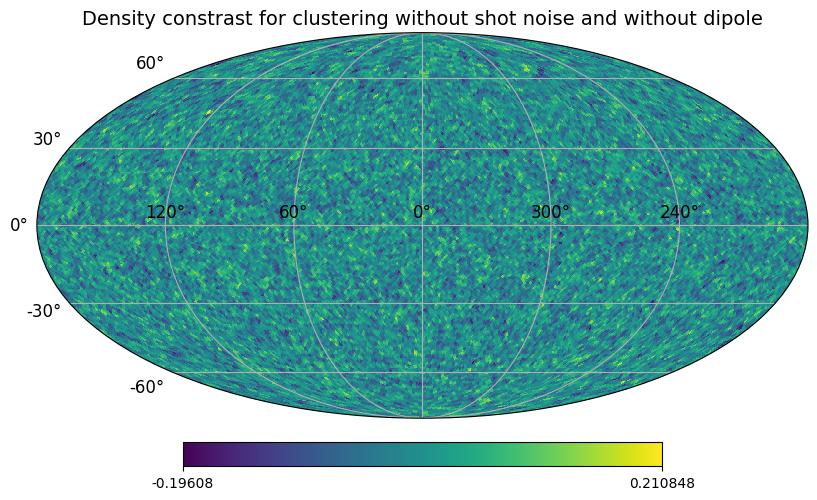

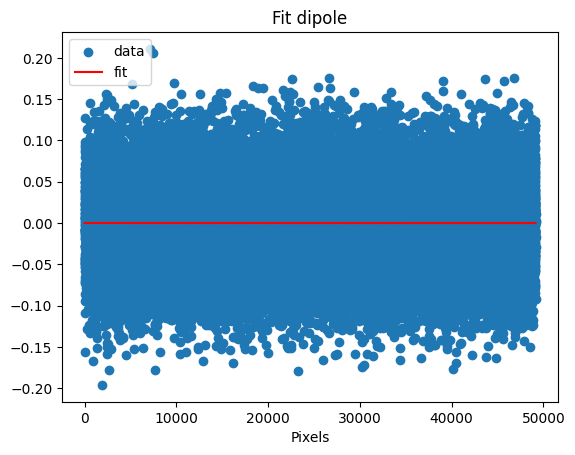

In [5]:
def get_clusterContrast(cl, nside, lognormal=False):
    m = hp.synfast(cl, nside=nside)
    if lognormal: m = np.exp(m - 0.5 * np.var(m)) #Log-Normale transformation
    return m

nest=False
lognormal=False
NSource_px_Cl = get_clusterContrast(cl, nside, lognormal=lognormal)

title="Density constrast for clustering without shot noise and without dipole"
hp.projview(NSource_px_Cl, title=title, graticule=True, graticule_labels=True)

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=nest, frame='icrs')
init =  (0, 3, 20, 40)
names = ("M", "A", "l", "b")
m = fit_dipole_err(model, NSource_px_Cl, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), fixed="M")

output_path = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "tests_fit"
get_saveFit_minuit(m, output_path, sufix, np.arange(0, npix), NSource_px_Cl, np.sqrt(np.abs(NSource_px_Cl)))
m

In [17]:
Ntrial = 50
output_path = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "tests_fit"
x_fit = np.arange(0, npix)
init =  (0, 3, 20, 40)
map_cl, fit_cl = [], []
for i in range(Ntrial):
    if i % 10 == 0: print(f'i = {i}', end = '\t')
    map = get_clusterContrast(cl, nside, lognormal=False)
    map_cl.append(map)
    m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), verbose=False, plot_fig=False, fixed='M')
    fit_cl.append(m)    
    y_fit_err = np.sqrt(np.abs(map))
    get_saveFit_minuit(m, output_path, sufix, x_fit, map, y_fit_err, verbose=False)
print('Saving complete.')

i = 0	i = 10	i = 20	i = 30	i = 40	Saving complete.


## Reading DataFrame

In [44]:
output_path = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "tests_fit"
df = pd.read_csv(output_path + sufix + '.csv')
df

,M,M_init,M_err,M_fixed,M_limits,A,A_init,A_err,A_fixed,A_limits,...,l_limits,b,b_init,b_err,b_fixed,b_limits,valid,x_fit,y_fit,y_fit_err
0,0.000000e+00,0.0,0.100000,True,"(0.0, inf)",7.830434e-05,1.0,0.001156,False,"(0.0, 1.0)",...,"(0.0, 360.0)",6.071985,40.0,130.954327,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([ 0.02293347, 0.07013103, -0.0470217...","np.array([0.15143801, 0.26482264, 0.21684492, ..."
1,0.000000e+00,0.0,0.100000,True,"(0.0, inf)",7.477426e-05,1.0,0.001391,False,"(0.0, 1.0)",...,"(0.0, 360.0)",3.993751,40.0,122.750363,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([-0.01851761, 0.02664854, 0.0231656...","np.array([0.13607942, 0.1632438 , 0.15220259, ..."
2,0.000000e+00,0.0,0.100000,True,"(0.0, inf)",7.732243e-05,1.0,0.001095,False,"(0.0, 1.0)",...,"(0.0, 360.0)",-47.733245,40.0,91.600619,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([0.03420074, 0.04048751, 0.01012297, ...","np.array([0.18493442, 0.20121507, 0.10061295, ..."
3,0.000000e+00,0.0,0.100000,True,"(0.0, inf)",9.419807e-05,1.0,0.000838,False,"(0.0, 1.0)",...,"(0.0, 360.0)",22.685472,40.0,141.476659,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([-0.00673276, -0.01669046, -0.0553291...","np.array([0.08205342, 0.12919156, 0.23522147, ..."
4,0.000000e+00,0.0,0.100000,True,"(0.0, inf)",6.075528e-05,1.0,0.001617,False,"(0.0, 1.0)",...,"(0.0, 360.0)",54.809655,40.0,109.984269,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([-0.03637137, -0.04595615, 0.0047000...","np.array([0.19071278, 0.21437386, 0.06855719, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,1.089667e-07,1000.0,0.001596,False,"(0.0, inf)",8.041027e-07,1.0,0.004092,False,"(0.0, 1.0)",...,"(0.0, 360.0)",-18.439201,40.0,102.855457,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([ 0.03761789, 0.0054757 , -0.0159318...","np.array([0.19395332, 0.073998 , 0.12622143, ..."
644,6.733206e-06,1000.0,0.004126,False,"(0.0, inf)",2.006727e-06,1.0,0.004518,False,"(0.0, 1.0)",...,"(0.0, 360.0)",-89.713370,40.0,150.263430,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([-0.05265183, -0.04548844, 0.0118784...","np.array([0.22945987, 0.2132802 , 0.10898818, ..."
645,4.464434e-08,1000.0,0.003022,False,"(0.0, inf)",1.009955e-07,1.0,0.007288,False,"(0.0, 1.0)",...,"(0.0, 360.0)",84.438691,40.0,163.949555,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([-0.03745246, -0.08828277, 0.0178890...","np.array([0.19352637, 0.29712417, 0.1337499 , ..."
646,9.017072e-10,1000.0,0.017510,False,"(0.0, inf)",1.826336e-09,1.0,0.003954,False,"(0.0, 1.0)",...,"(0.0, 360.0)",-89.999818,40.0,153.644106,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([ 0.03042208, 0.02496456, -0.0031950...","np.array([0.17441926, 0.15800179, 0.05652466, ..."


In [45]:
mask = (df['valid'] == True) #to select only valid minima in figt.
print("Nb. of non-valid minimum :", len(df[~mask]))
print(f"Ratio of non-valid minimum : {100*len(df[~mask])/len(df)} %")
df = df[mask]
print(f"Nb. of valid minimum : {len(df)}\n")
print(f"A mean = {df['A'].mean()} +/- {df['A_err'].mean()}")
print(f"A STD = {df['A'].std()}")
df[[col for col in df.columns if not col.endswith('init')]].describe()

Nb. of non-valid minimum : 16
Ratio of non-valid minimum : 2.4691358024691357 %
Nb. of valid minimum : 632

A mean = 4.651383919680273e-05 +/- 0.006568592836525127
A STD = 4.2113773560974e-05


,M,M_err,A,A_err,l,l_err,b,b_err
count,6.320000e+02,632.000000,6.320000e+02,632.000000,6.320000e+02,632.000000,632.000000,632.000000
mean,4.516446e-06,0.054216,4.651384e-05,0.006569,1.076920e+02,261.374962,3.017406,131.249631
std,1.044572e-05,0.085818,4.211377e-05,0.046252,1.091047e+02,53.814615,58.900902,24.213810
min,0.000000e+00,0.000003,2.581060e-12,0.000010,1.976513e-07,0.349013,-90.000000,0.353839
25%,0.000000e+00,0.002026,2.103592e-06,0.001023,4.955088e+00,213.623565,-46.501846,111.056943
50%,5.066059e-14,0.009850,4.245710e-05,0.001647,8.298634e+01,261.323066,3.715074,132.385519
75%,2.099313e-06,0.100000,7.512707e-05,0.003400,1.741599e+02,307.637526,53.807659,152.480104
max,7.027329e-05,1.367503,1.889924e-04,0.934392,3.599999e+02,359.997024,90.000000,179.876434


/tmp/ipykernel_809/4233272295.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['costheta'] = df.apply(get_costheta, axis=1)


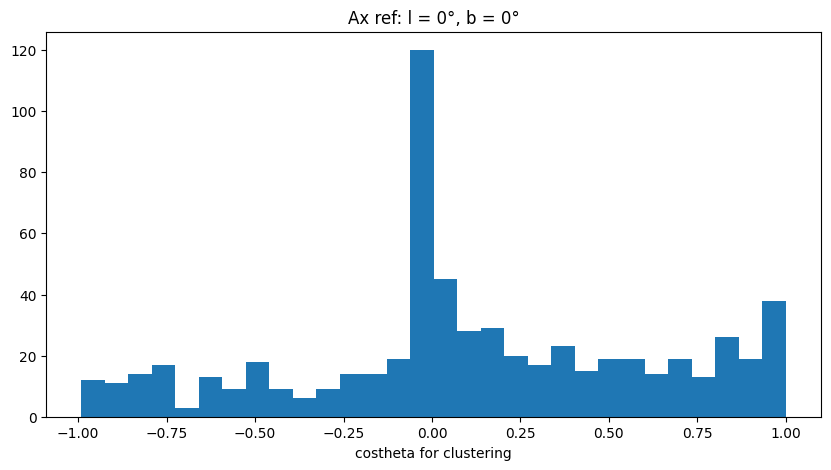

In [46]:
def get_costheta(df, lref=0, bref=0):
    data = df.copy()
    dipole = SkyCoord(l=data['l']*u.degree, b=data['b']*u.degree, frame='galactic')
    u_dipole = dipole.cartesian.xyz.value
    axref = SkyCoord(l=lref*u.degree, b=bref*u.degree, frame='galactic')
    u_ref = axref.cartesian.xyz.value
    return np.dot(u_dipole, u_ref)

df['costheta'] = df.apply(get_costheta, axis=1)
col = 'costheta'
fig, ax = plt.subplots(figsize=[10, 5])
get_hist(df[col], xlabel=f"{col} for clustering", bins=30, figax=(fig, ax), title="Ax ref: l = 0°, b = 0°");

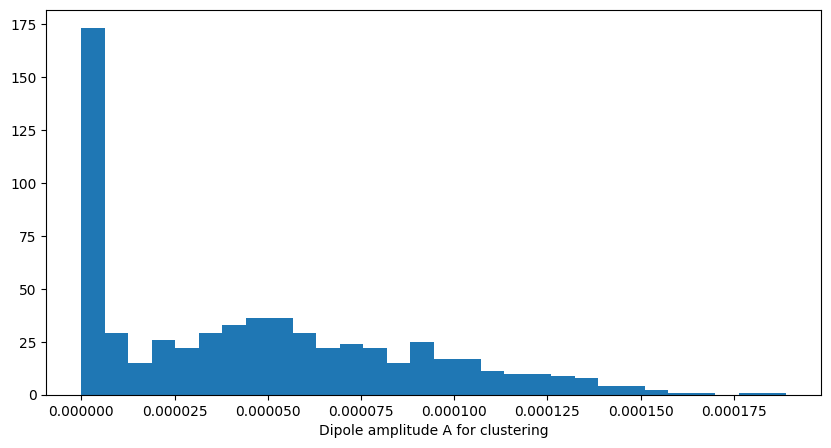

In [47]:
col = 'A'
fig, ax = plt.subplots(figsize=[10, 5])
var, bins = get_hist(df[col], xlabel=f"Dipole amplitude {col} for clustering", bins=30, figax=(fig, ax), show=False)
# ax.set_xscale('log')
# ax.set_yscale('log');

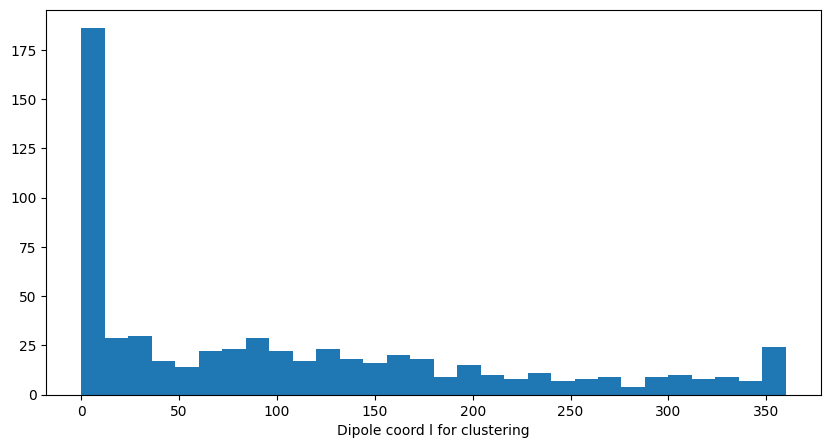

In [48]:
col = 'l'
fig, ax = plt.subplots(figsize=[10, 5])
get_hist(df[col], xlabel=f"Dipole coord {col} for clustering", bins=30, figax=(fig, ax));

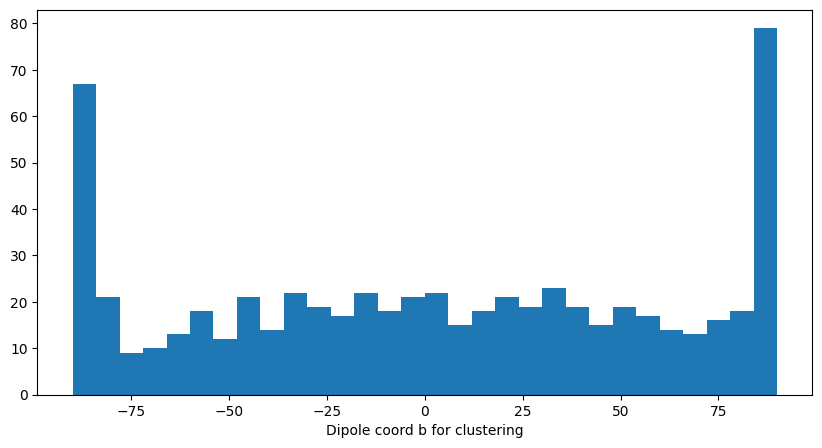

In [49]:
col = 'b'
fig, ax = plt.subplots(figsize=[10, 5])
get_hist(df[col], xlabel=f"Dipole coord {col} for clustering", bins=30, figax=(fig, ax));

## Only M fixed

In [50]:
df_Mfixed = df[df['M_fixed']]
df_Mfixed[[col for col in df_Mfixed.columns if not col.endswith('init')]].describe()

,M,M_err,A,A_err,l,l_err,b,b_err,costheta
count,306.0,3.060000e+02,3.060000e+02,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000
mean,0.0,1.000000e-01,5.605903e-05,0.005340,83.184616,260.931077,13.298360,128.744122,0.120385
std,0.0,1.390052e-17,3.991105e-05,0.038360,93.573905,52.626746,53.856441,23.464085,0.540655
min,0.0,1.000000e-01,5.270558e-10,0.000049,0.000002,108.383681,-89.999965,90.152890,-0.990922
25%,0.0,1.000000e-01,2.582702e-05,0.000900,0.327590,213.033929,-30.904181,108.816113,-0.168588
50%,0.0,1.000000e-01,5.163415e-05,0.001443,54.185700,259.670524,13.750159,128.647771,0.075035
75%,0.0,1.000000e-01,8.480439e-05,0.002282,139.290173,307.224948,58.826031,148.495876,0.569583
max,0.0,1.000000e-01,1.551784e-04,0.648305,359.999275,359.997024,90.000000,179.876434,1.000000


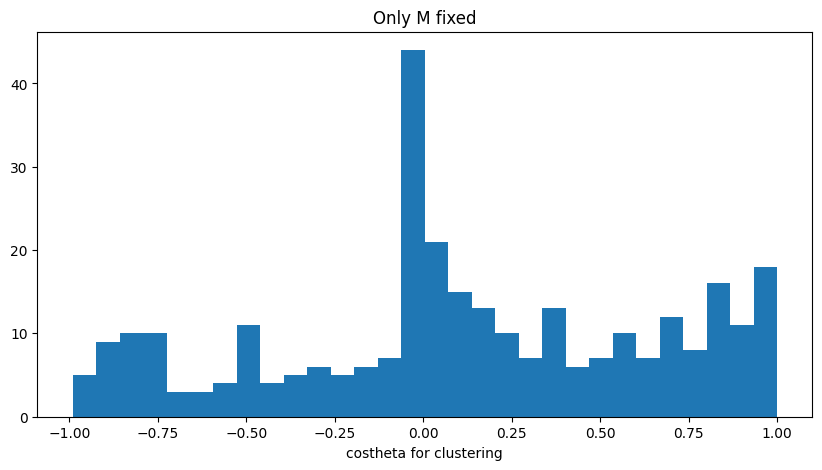

In [51]:
col = 'costheta'
fig, ax = plt.subplots(figsize=[10, 5])
get_hist(df_Mfixed[col], xlabel=f"{col} for clustering", bins=30, figax=(fig, ax), title="Only M fixed");

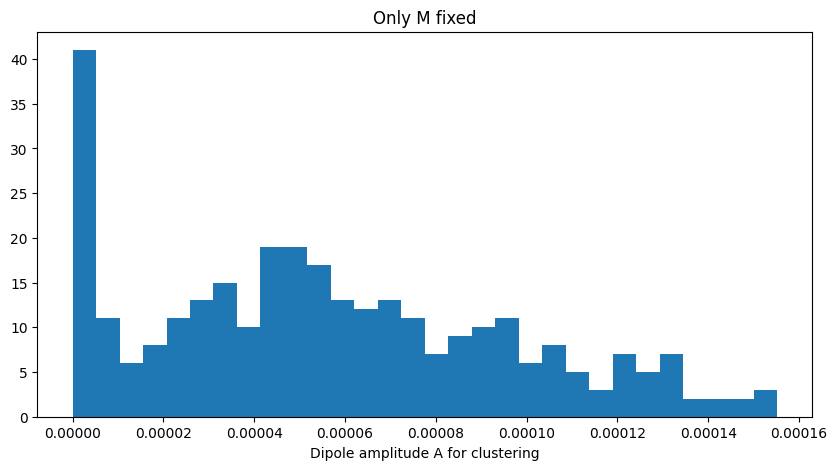

In [55]:
col = 'A'
fig, ax = plt.subplots(figsize=[10, 5])
var, bins = get_hist(df_Mfixed[col], xlabel=f"Dipole amplitude {col} for clustering", bins=30, figax=(fig, ax), title="Only M fixed");

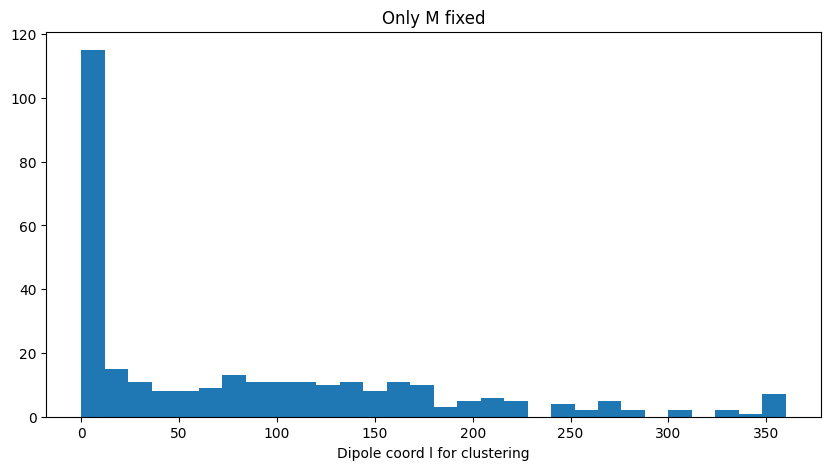

In [53]:
col = 'l'
fig, ax = plt.subplots(figsize=[10, 5])
var, bins = get_hist(df_Mfixed[col], xlabel=f"Dipole coord {col} for clustering", bins=30, figax=(fig, ax), title="Only M fixed");

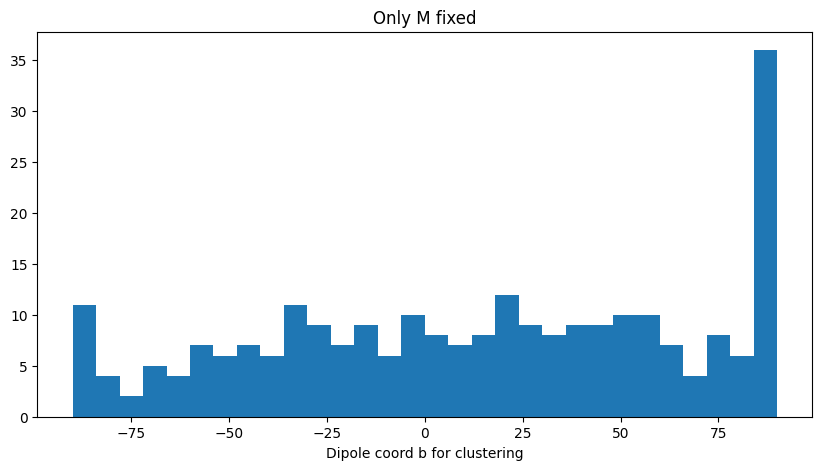

In [16]:
col = 'b'
fig, ax = plt.subplots(figsize=[10, 5])
var, bins = get_hist(df_Mfixed[col], xlabel=f"Dipole coord {col} for clustering", bins=30, figax=(fig, ax), title="Only M fixed");

## Other fit method

In [36]:
def build_mask(nside):
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))

    # hémisphère sud
    mask = (theta > np.pi/2).astype(float)

    # retirer plan galactique |b| < 5°
    b = np.pi/2 - theta
    mask[np.abs(b) < np.deg2rad(5)] = 0.

    return mask


def estimate_dipole_mle(counts, mask=1, nside=nside):
    npix = len(counts)
    theta, phi = hp.pix2ang(nside, np.arange(npix))

    n_hat = np.vstack([
        np.sin(theta)*np.cos(phi),
        np.sin(theta)*np.sin(phi),
        np.cos(theta)
    ]).T

    w = mask
    y = counts# / np.mean(counts) - 1

    A = (n_hat.T * w) @ n_hat
    b = (n_hat.T * w) @ y

    d = np.linalg.solve(A, b)

    return d


Ntrial = 10000
map_cl, fit_cl, map_IDs = [], [], []
for i in range(Ntrial):
    if i % 1000 == 0: print(f'i = {i}', end = '\t')
    map, map_id  = get_clusterContrast(cl, nside, lognormal=False), ULID()
    map_cl.append(map)
    map_IDs.append(map_id)
    d = estimate_dipole_mle(map, mask=1)
    fit_cl.append(d)

dfMaps = {'Map_ID': np.array(map_IDs, dtype='S26'), 'Map': np.array(map_cl)}
dfMC = {'Map_ID': np.array(map_IDs, dtype='S26'),'A' : np.linalg.norm(fit_cl, axis=1)}
dfMC['Dx'], dfMC['Dy'], dfMC['Dz'] = tuple(np.array(fit_cl).T)

print("\nMean:", np.mean(fit_cl, axis=0))
print("Std :", np.std(fit_cl, axis=0))
print("Amplitude:", np.mean(np.linalg.norm(fit_cl, axis=1)))
#dfMC

i = 0	i = 1000	i = 2000	i = 3000	i = 4000	i = 5000	i = 6000	i = 7000	i = 8000	i = 9000	
Mean: [-1.37986032e-06 -2.01715767e-06  4.72823623e-06]
Std : [0.00044241 0.00044175 0.00044239]
Amplitude: 0.0007056936687166427


In [37]:
import fitsio

outputfile = output_path + sufix + '.fits'
header_global = {'MAP_TYPE': 'Clustering', 'INJECT_DIPOLE': False}
with fitsio.FITS(outputfile, 'rw', clobber=True) as fits: #Ouvrir le fichier en mode écriture ('rw' crée ou écrase)
    
    # Ajouter une PrimaryHDU avec des métadonnées globales
    fits.write(None, header=header_global) # None car la Primary est vide de données
    
    # Ajouter le premier DataFrame (Extension 1)
    # extname donne un nom à l'HDU pour s'y retrouver
    fits.write(dfMaps, extname='MAPS')
    
    # Ajouter le second DataFrame (Extension 2)
    fits.write(dfMC, extname='FIT_RESULTS')

print("Sauvegarde terminée avec succès !")

Sauvegarde terminée avec succès !


In [2]:
import fitsio

output_path = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "tests_fit"
outputfile = output_path + sufix + '.fits'

data = fitsio.FITS(outputfile)
data['MAPS'].read()

array([('01KNPVZ2917D8HX6Q6RFBEVV2V', [-5.54602799e-03, -6.71584892e-02,  3.02132274e-02, ...,  2.38780112e-02,  4.26996483e-02, -3.64835822e-02]),
       ('01KNPVZ29AGSPFAM32H9G15997', [ 5.03347963e-02, -6.88072070e-02, -5.42670878e-02, ..., -3.52190605e-02, -5.41107178e-02,  3.42133461e-03]),
       ('01KNPVZ29NVYM1FPF7R7RFBP0E', [ 3.72905324e-02,  4.88672935e-02,  2.12885795e-02, ...,  3.55835180e-02,  4.12473107e-02, -3.90187020e-02]),
       ...,
       ('01KNPW0XPQ8S24VQ9MSERSHA9P', [-5.67836022e-03, -2.87181826e-02, -2.54086867e-02, ..., -1.04321534e-02,  7.27712167e-02,  2.94591192e-02]),
       ('01KNPW0XPXKSC133JG48EAVQE3', [ 2.05973331e-02,  1.75417524e-03,  4.15530194e-02, ...,  7.04019469e-02,  4.01055295e-02,  5.30723913e-02]),
       ('01KNPW0XQ8AAS4X02R8JAYQ212', [-1.07351348e-02, -6.52387841e-03,  5.34384911e-02, ..., -4.52758791e-02, -9.66282479e-02,  1.11508711e-03])],
      dtype=[('Map_ID', '<U26'), ('Map', '>f8', (49152,))])

In [35]:
dfMC = pd.DataFrame(dfMC)
dfMC

,Map_ID,A,Dx,Dy,Dz
0,b'01KNPVSZHH9HWG49BZK1R7CW5Z',0.000390,-0.000127,-0.000312,0.000197
1,b'01KNPVSZK1BKTWP4ARZVW270CX',0.001083,0.000526,-0.000195,0.000927
2,b'01KNPVSZK7NW04J1Y9C6A99V8Q',0.000936,0.000182,0.000911,0.000114
3,b'01KNPVSZKCWSC00NAKSC8H225H',0.001116,-0.000735,0.000005,-0.000841
4,b'01KNPVSZKJD0D4N5232J6ZKEB7',0.000407,-0.000398,-0.000023,0.000081
...,...,...,...,...,...
995,b'01KNPVT622FNX0WR7GNXBAKGHY',0.000422,0.000170,-0.000141,-0.000360
996,b'01KNPVT62846KDZ0BZB2MQ9J5S',0.000381,0.000132,0.000349,-0.000079
997,b'01KNPVT62EJNMFN4KYA6XJPHZM',0.001220,0.000747,0.000120,0.000958
998,b'01KNPVT62MZCCH4KZNFVH70K15',0.000485,0.000039,0.000352,-0.000331


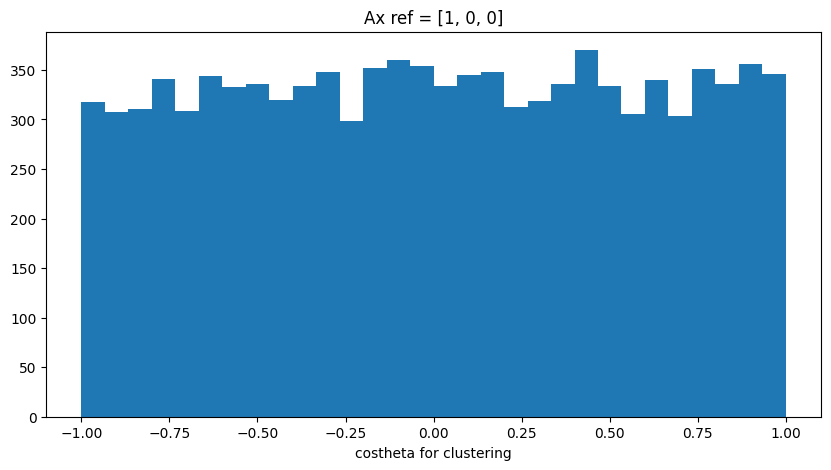

In [10]:
def get_costheta_cartesian(df, axref=[1, 0, 0]):
    data = df.copy()
    axref = np.array(axref)
    axref = axref/np.linalg.norm(axref)
    dip = np.array(data[['Dx', 'Dy', 'Dz']])
    return np.dot(dip, axref)/data['A']

axref = [1, 0, 0]
dfMC['costheta'] = dfMC.apply(get_costheta_cartesian, axis=1, args=(axref,))
col = 'costheta'
fig, ax = plt.subplots(figsize=[10, 5])
get_hist(dfMC[col], xlabel=f"{col} for clustering", bins=30, figax=(fig, ax), title=f"Ax ref = {axref}");

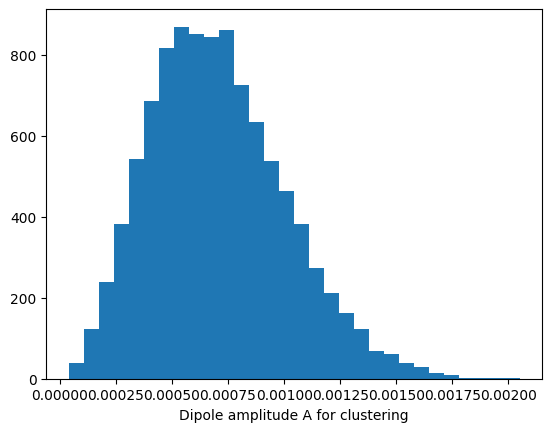

In [42]:
col = 'A'
fig, ax = plt.subplots()
get_hist(dfMC[col], xlabel=f"Dipole amplitude {col} for clustering", bins=30, figax=(fig, ax));

In [43]:
dfMC.describe()

,A,Dx,Dy,Dz,costheta
count,10000.000000,1.000000e+04,10000.000000,1.000000e+04,10000.000000
mean,0.000705,2.359515e-06,0.000001,3.900965e-06,0.002210
std,0.000302,4.456994e-04,0.000440,4.427965e-04,0.578609
min,0.000039,-1.583677e-03,-0.001561,-1.626704e-03,-0.999709
25%,0.000481,-2.935258e-04,-0.000295,-2.983184e-04,-0.498947
50%,0.000676,5.586708e-07,0.000005,5.890644e-07,0.001043
75%,0.000897,2.982116e-04,0.000290,3.032341e-04,0.506378
max,0.002049,1.625216e-03,0.001697,1.721673e-03,0.999964
